In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, random_split
from scipy.ndimage import gaussian_filter1d
from nlb_tools.nwb_interface import NWBDataset
from config import Config
from data import load_mcmaze, gaussian_smooth, make_windows, train_val_split
import random



In [2]:
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


In [3]:
# def load_mcmaze(nwb_path: str, bin_ms: int = 5):
#     """Load MC_Maze train NWB, resample to bin_ms, return spike array and trial info.

#     Returns
#     -------
#     spikes_raw : np.ndarray, shape (C, T_total), float32
#         Raw spike counts. NaN entries (inter-trial gaps in NLB format) are filled with 0.
#     bin_width_s : float
#         Bin duration in seconds.
#     trial_info : pd.DataFrame
#         Trial table with at least start_time and end_time columns.
#     """
#     ds = NWBDataset(nwb_path)
#     ds.resample(bin_ms)

#     spikes_df = ds.data["spikes"]           # (T_total, C)
#     spikes_raw = spikes_df.values.T.astype(np.float32)  # (C, T_total)
#     spikes_raw = np.nan_to_num(spikes_raw, nan=0.0)

#     bin_width_s = bin_ms * 1e-3
#     trial_info = ds.trial_info
#     # Normalise time columns to seconds (stored as timedelta64[ns] in NLB datasets)
#     for col in ["start_time", "end_time", "stop_time"]:
#         if col in trial_info.columns:
#             delta = trial_info[col]
#             if hasattr(delta, "dt"):
#                 trial_info = trial_info.copy()
#                 trial_info[col] = delta.dt.total_seconds().values
#             elif np.issubdtype(delta.dtype, np.timedelta64):
#                 trial_info = trial_info.copy()
#                 trial_info[col] = delta.values.astype("float64") / 1e9

#     # Store the global time index (in seconds) so we can map trial times → bin indices
#     time_index_s = spikes_df.index.values
#     if np.issubdtype(time_index_s.dtype, np.timedelta64):
#         time_index_s = time_index_s.astype("float64") / 1e9
#     else:
#         time_index_s = time_index_s.astype("float64")

#     return spikes_raw, bin_width_s, trial_info, time_index_s


In [4]:
cfg = Config()
set_seed(cfg.seed)

print("Loading MC_Maze data …")
spikes_raw, bin_width_s, trial_info, time_index_s = load_mcmaze(cfg.nwb_path, cfg.bin_ms)
C = spikes_raw.shape[0]
print(f"  Channels: {C}  |  Bin width: {cfg.bin_ms} ms  |  Trials: {len(trial_info)}")

sigma_samples = round((cfg.sigma_ms * 1e-3) / bin_width_s)
print(f"  Gaussian smoothing sigma: {cfg.sigma_ms} ms = {sigma_samples} bins")
X_smooth = gaussian_smooth(spikes_raw, sigma_samples)

print(f"Windowing ({cfg.window_strategy}, T={cfg.window_size}) …")
windows = make_windows(
    X_smooth, trial_info, time_index_s, bin_width_s,
    strategy=cfg.window_strategy, window_size=cfg.window_size,
)
print(f"  Windows shape: {windows.shape}  (K, N, T)")

train_ds, val_ds = train_val_split(windows, cfg.val_split, cfg.seed)
print(f"  Train: {len(train_ds)}  |  Val: {len(val_ds)}")

Loading MC_Maze data …
  Channels: 98  |  Bin width: 5 ms  |  Trials: 1080
  Gaussian smoothing sigma: 10.0 ms = 2 bins
Windowing (trial_aligned, T=120) …
  Windows shape: (1080, 98, 120)  (K, N, T)
  Train: 972  |  Val: 108


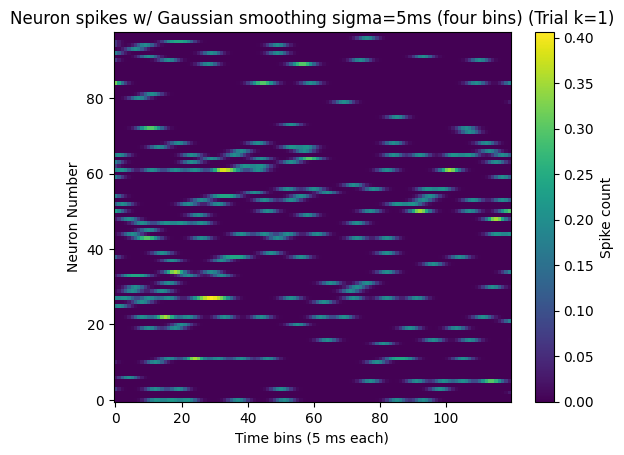

In [6]:
plt.imshow(windows[1,:,:], aspect="auto", origin="lower")
plt.xlabel("Time bins ({} ms each)".format(cfg.bin_ms))
plt.ylabel("Neuron Number")
plt.title("Neuron spikes w/ Gaussian smoothing sigma=5ms (four bins) (Trial k=1)")
plt.colorbar(label="Spike count")
plt.show()